# Multivariate Regression Epidemics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
cwd = os.getcwd()
print(cwd)

c:\Users\danie\Documents\GitHub\thesis\modelling


In [7]:
df = pd.read_csv('../Data/gold/epidemics.csv')
df.head()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,wdir,wspd,pres,mob_index,google_physician,google_hospital,google_pharmacy,google_symptom
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,180.781498,10.676055,1014.549139,7.531667,28,10,6,44
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,82.957584,10.251907,1013.957489,4.344286,31,8,6,40
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,54.720690,10.745449,1014.803952,2.705714,40,8,6,38
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,158.256566,9.985720,1016.499355,1.977143,27,8,5,31
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,121.429786,8.996266,1015.642953,2.207143,24,7,5,29


# Wrangle

# CREATE CUMULATIVE TARGET

In [8]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom'],
      dtype='object')

In [9]:
df['dengue_t_1'] = df['dengue'].shift(-1)
df['zika_t_1'] = df['zika'].shift(-1)
df['chik_t_1'] = df['chik'].shift(-1)
df['var_t_1'] = df['var'].shift(-1)


In [10]:
print(df['dengue_t_1'].isnull().sum(), 'Nans for dengue +1')
print(df['zika_t_1'].isnull().sum(), 'Nans for zika + 1')
print(df['chik_t_1'].isnull().sum(), 'Nans for chikungunya +1')
print(df['var_t_1'].isnull().sum(), 'Nans for chickenpox +1')

1 Nans for dengue +1
1 Nans for zika + 1
1 Nans for chikungunya +1
1 Nans for chickenpox +1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              197 non-null    object 
 1   dengue            197 non-null    int64  
 2   zika              197 non-null    float64
 3   chik              197 non-null    float64
 4   var               197 non-null    float64
 5   date              197 non-null    object 
 6   tavg              197 non-null    float64
 7   tmin              197 non-null    float64
 8   tmax              197 non-null    float64
 9   prcp              197 non-null    float64
 10  wdir              197 non-null    float64
 11  wspd              197 non-null    float64
 12  pres              197 non-null    float64
 13  mob_index         197 non-null    float64
 14  google_physician  197 non-null    int64  
 15  google_hospital   197 non-null    int64  
 16  google_pharmacy   197 non-null    int64  
 1

In [13]:
# drop nans
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196 entries, 0 to 195
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              196 non-null    object 
 1   dengue            196 non-null    int64  
 2   zika              196 non-null    float64
 3   chik              196 non-null    float64
 4   var               196 non-null    float64
 5   date              196 non-null    object 
 6   tavg              196 non-null    float64
 7   tmin              196 non-null    float64
 8   tmax              196 non-null    float64
 9   prcp              196 non-null    float64
 10  wdir              196 non-null    float64
 11  wspd              196 non-null    float64
 12  pres              196 non-null    float64
 13  mob_index         196 non-null    float64
 14  google_physician  196 non-null    int64  
 15  google_hospital   196 non-null    int64  
 16  google_pharmacy   196 non-null    int64  
 17  go

In [14]:
# convert date to numeric
df['date'] = pd.to_datetime(df['date'])
df['date_numeric'] = df['date'].apply(lambda x: x.timestamp())

In [15]:
df_og = df.copy()

# Regression Framework

In [22]:
targets = ['dengue_t_1', 'zika_t_1', 'chik_t_1', 'var_t_1']

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer

In [24]:

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer


def evaluate_metrics_cv(df, targets, model, n_splits=5):

    metrics = {}

    for target_variable in targets:
        split_idx = int(len(df) * 0.8)
        # drop columns
        drop_columns = targets + ['date', 'week']

        X = df.drop(columns=drop_columns)
        y = df[target_variable]
        
        # train-test split
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

        # mark dummies
        dummy_cols = [col for col in X.columns if set(X[col].unique()) <= {0, 1}]
        numeric_cols = [col for col in X.columns if col not in dummy_cols]
        
        # standard scaling
        scaler = StandardScaler()
        X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
        X_test_scaled_numeric = scaler.transform(X_test[numeric_cols])

        X_train_scaled = np.concatenate([X_train_scaled_numeric, X_train[dummy_cols].values], axis=1)
        X_test_scaled = np.concatenate([X_test_scaled_numeric, X_test[dummy_cols].values], axis=1)
        # cross validation
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        mse_scores = cross_val_score(model, X_train_scaled, y_train, 
                                     scoring=make_scorer(mean_squared_error), cv=kf)
        rmse_cv = np.sqrt(mse_scores).mean()

        r2_cv = cross_val_score(model, X_train_scaled, y_train, scoring='r2', cv=kf).mean()
        # model fitting
        model.fit(X_train_scaled, y_train)
        # predictions
        y_pred_test = model.predict(X_test_scaled)
        # metrics
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        r2_test = r2_score(y_test, y_pred_test)

        metrics[target_variable] = {
            'RMSE_CV': rmse_cv,
            'R2_CV': r2_cv,
            'RMSE_Test': rmse_test,
            'R2_Test': r2_test
        }
    return metrics


In [25]:
mets = evaluate_metrics_cv(df, targets, LinearRegression())
mets

{'dengue_t_1': {'RMSE_CV': 83.133563158313,
  'R2_CV': 0.9476261328773654,
  'RMSE_Test': 184.21041309147742,
  'R2_Test': 0.9060643952153875},
 'zika_t_1': {'RMSE_CV': 1.0793633603549917,
  'R2_CV': -0.04212030614319904,
  'RMSE_Test': 0.8609848845708522,
  'R2_Test': -0.1582733929054434},
 'chik_t_1': {'RMSE_CV': 1.2715500622422589,
  'R2_CV': -0.3697444889987188,
  'RMSE_Test': 1.2088680519962982,
  'R2_Test': -0.2203440226616491},
 'var_t_1': {'RMSE_CV': 39.62553121623285,
  'R2_CV': 0.9275953974795168,
  'RMSE_Test': 51.536457912987075,
  'R2_Test': 0.8917710743075651}}

In [27]:
def evaluate_models_rmse(df, targets):
    models = {
        'LinearRegression': LinearRegression(),
        'Lasso': Lasso(alpha=1.0),
        'Ridge': Ridge(alpha=1.0),
        'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
        'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'SVR': SVR(kernel='rbf')
    }

    all_metrics = []

    for model_name, model in models.items():
        metrics = evaluate_metrics_cv(df, targets, model)
        for target, scores in metrics.items():
            all_metrics.append({
                'Model': model_name,
                'Epidemic': target,
                'RMSE': scores['RMSE_Test'],
                'R2': scores['R2_Test']
            })

    metrics_df = pd.DataFrame(all_metrics)
    return metrics_df



In [28]:
df_metrics_all = evaluate_models_rmse(df,targets)
df_metrics_all

,Model,Epidemic,RMSE,R2
0,LinearRegression,dengue_t_1,184.210413,0.906064
1,LinearRegression,zika_t_1,0.860985,-0.158273
2,LinearRegression,chik_t_1,1.208868,-0.220344
3,LinearRegression,var_t_1,51.536458,0.891771
4,Lasso,dengue_t_1,186.944646,0.903255
5,Lasso,zika_t_1,0.862774,-0.163092
6,Lasso,chik_t_1,1.095891,-0.002904
7,Lasso,var_t_1,55.254383,0.875592
8,Ridge,dengue_t_1,191.003770,0.899008
9,Ridge,zika_t_1,0.863195,-0.164228


In [29]:
df_rmse_pivot = df_metrics_all.pivot(index = 'Epidemic', columns='Model', values='RMSE').reset_index()
df_rmse_pivot

Model,Epidemic,ElasticNet,GradientBoosting,Lasso,LinearRegression,RandomForest,Ridge,SVR
0,chik_t_1,1.095891,1.551548,1.095891,1.208868,1.398072,1.206077,1.118496
1,dengue_t_1,541.596082,1072.165755,186.944646,184.210413,1033.670631,191.003770,1515.295188
2,var_t_1,131.499106,203.429784,55.254383,51.536458,194.516614,52.904868,397.406237
3,zika_t_1,0.862774,2.712128,0.862774,0.860985,1.415297,0.863195,0.785089


In [30]:
df_r2_pivot = df_metrics_all.pivot(index = 'Epidemic', columns='Model', values='R2').reset_index()
df_r2_pivot

Model,Epidemic,ElasticNet,GradientBoosting,Lasso,LinearRegression,RandomForest,Ridge,SVR
0,chik_t_1,-0.002904,-1.010271,-0.002904,-0.220344,-0.632238,-0.214715,-0.044704
1,dengue_t_1,0.188006,-2.182187,0.903255,0.906064,-1.957783,0.899008,-5.356183
2,var_t_1,0.295372,-0.686333,0.875592,0.891771,-0.541798,0.885947,-5.435519
3,zika_t_1,-0.163092,-10.493184,-0.163092,-0.158273,-2.129789,-0.164228,0.036929


# Explanatory variables

We now implement a version which compares all the countries in a single model so it can consider differences in variables such as population density

In [31]:
# plot only forecast (test)
def plot_predictions_cv_forecast(df, targets, model, n_splits=5):

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    for idx, target in enumerate(targets):
        

        split_idx = int(len(df) * 0.8)

        drop_columns = targets + ['date', 'week']

        X = df.drop(columns=drop_columns)
        y = df[target]
        
        # train-test split
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

        # mark dummies
        dummy_cols = [col for col in X.columns if set(X[col].unique()) <= {0, 1}]
        numeric_cols = [col for col in X.columns if col not in dummy_cols]
        
        # standard scaling
        scaler = StandardScaler()
        X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
        X_test_scaled_numeric = scaler.transform(X_test[numeric_cols])

        X_train_scaled = np.concatenate([X_train_scaled_numeric, X_train[dummy_cols].values], axis=1)
        X_test_scaled = np.concatenate([X_test_scaled_numeric, X_test[dummy_cols].values], axis=1)
        # cross validation
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        mse_scores = cross_val_score(model, X_train_scaled, y_train, 
                                     scoring=make_scorer(mean_squared_error), cv=kf)
        rmse_cv = np.sqrt(mse_scores).mean()

        r2_cv = cross_val_score(model, X_train_scaled, y_train, scoring='r2', cv=kf).mean()
        # model fitting
        model.fit(X_train_scaled, y_train)
        # predictions
        y_pred_test = model.predict(X_test_scaled)

        axes[idx].plot(df['date'].iloc[split_idx:], y_test, label='Actual', color='blue')
        axes[idx].plot(df['date'].iloc[split_idx:], y_pred_test, label='Predicted', color='red', linestyle='--')

        axes[idx].set_title(f'{target}', fontsize=14)
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel(target)
        axes[idx].legend()

    if len(targets) < len(axes):
        for ax in axes[len(targets):]:
            fig.delaxes(ax)

    plt.tight_layout()
    plt.show()


# Plots
All Models

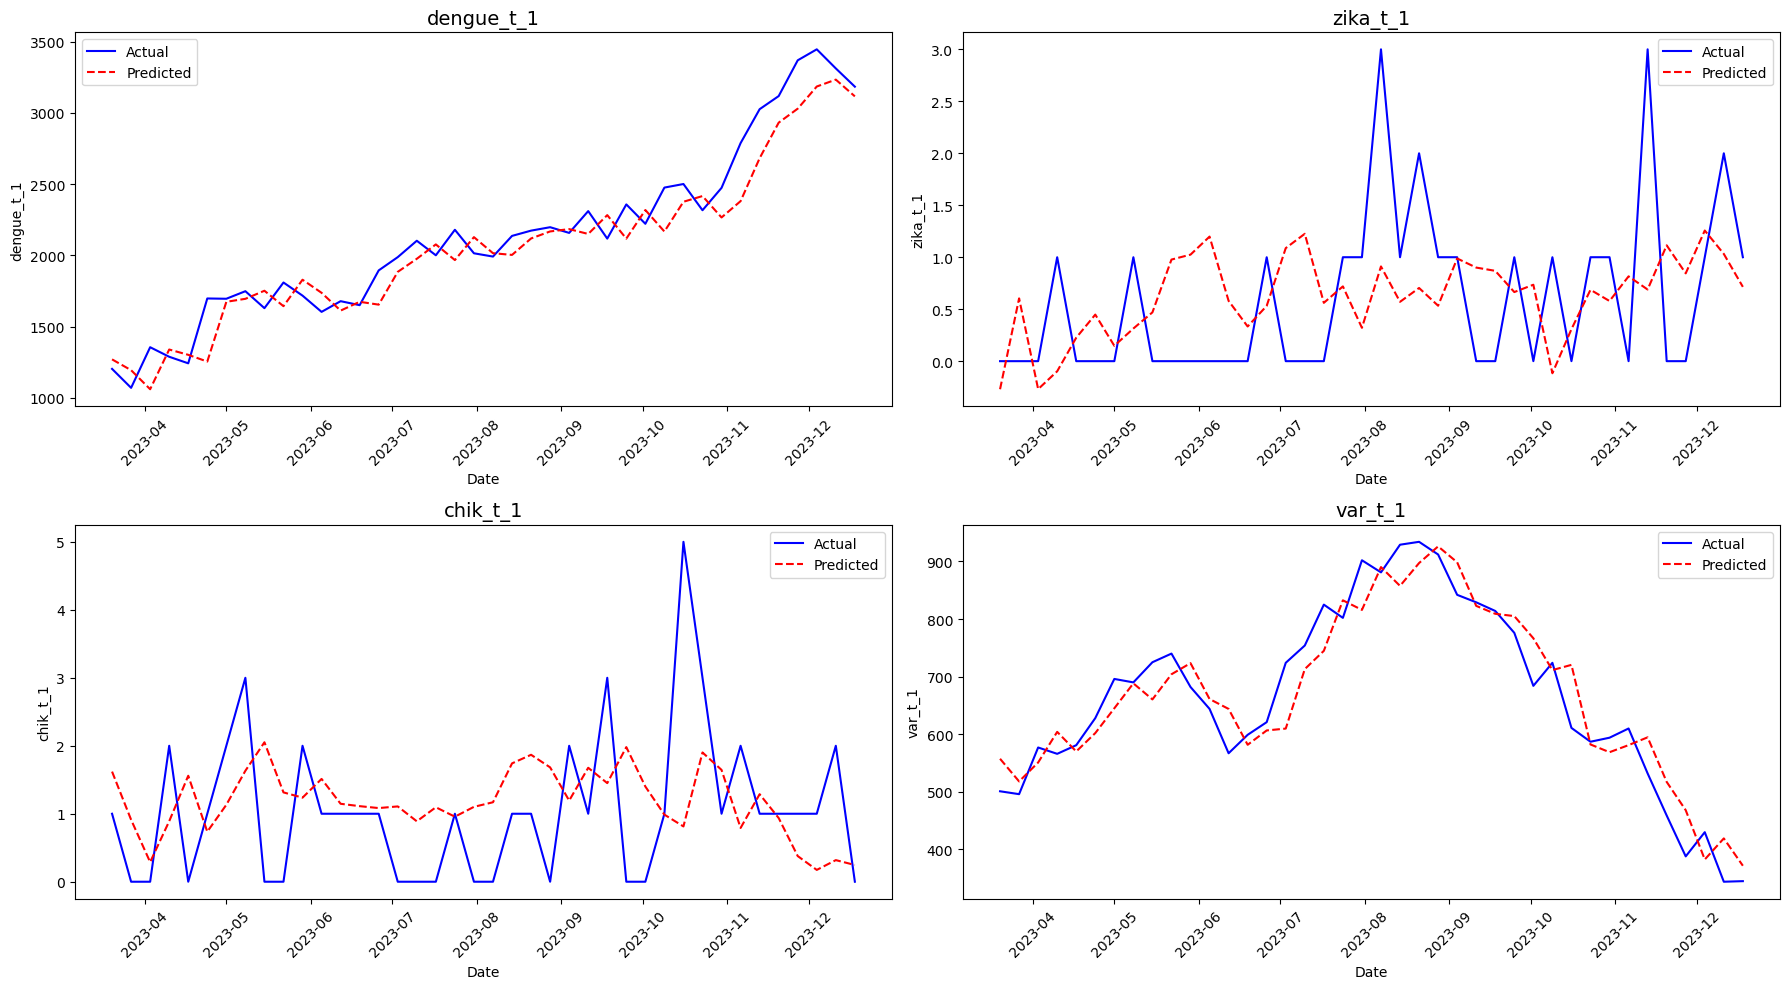

In [32]:
# Linear regression
plot_predictions_cv_forecast(df, targets, LinearRegression(), n_splits=5)

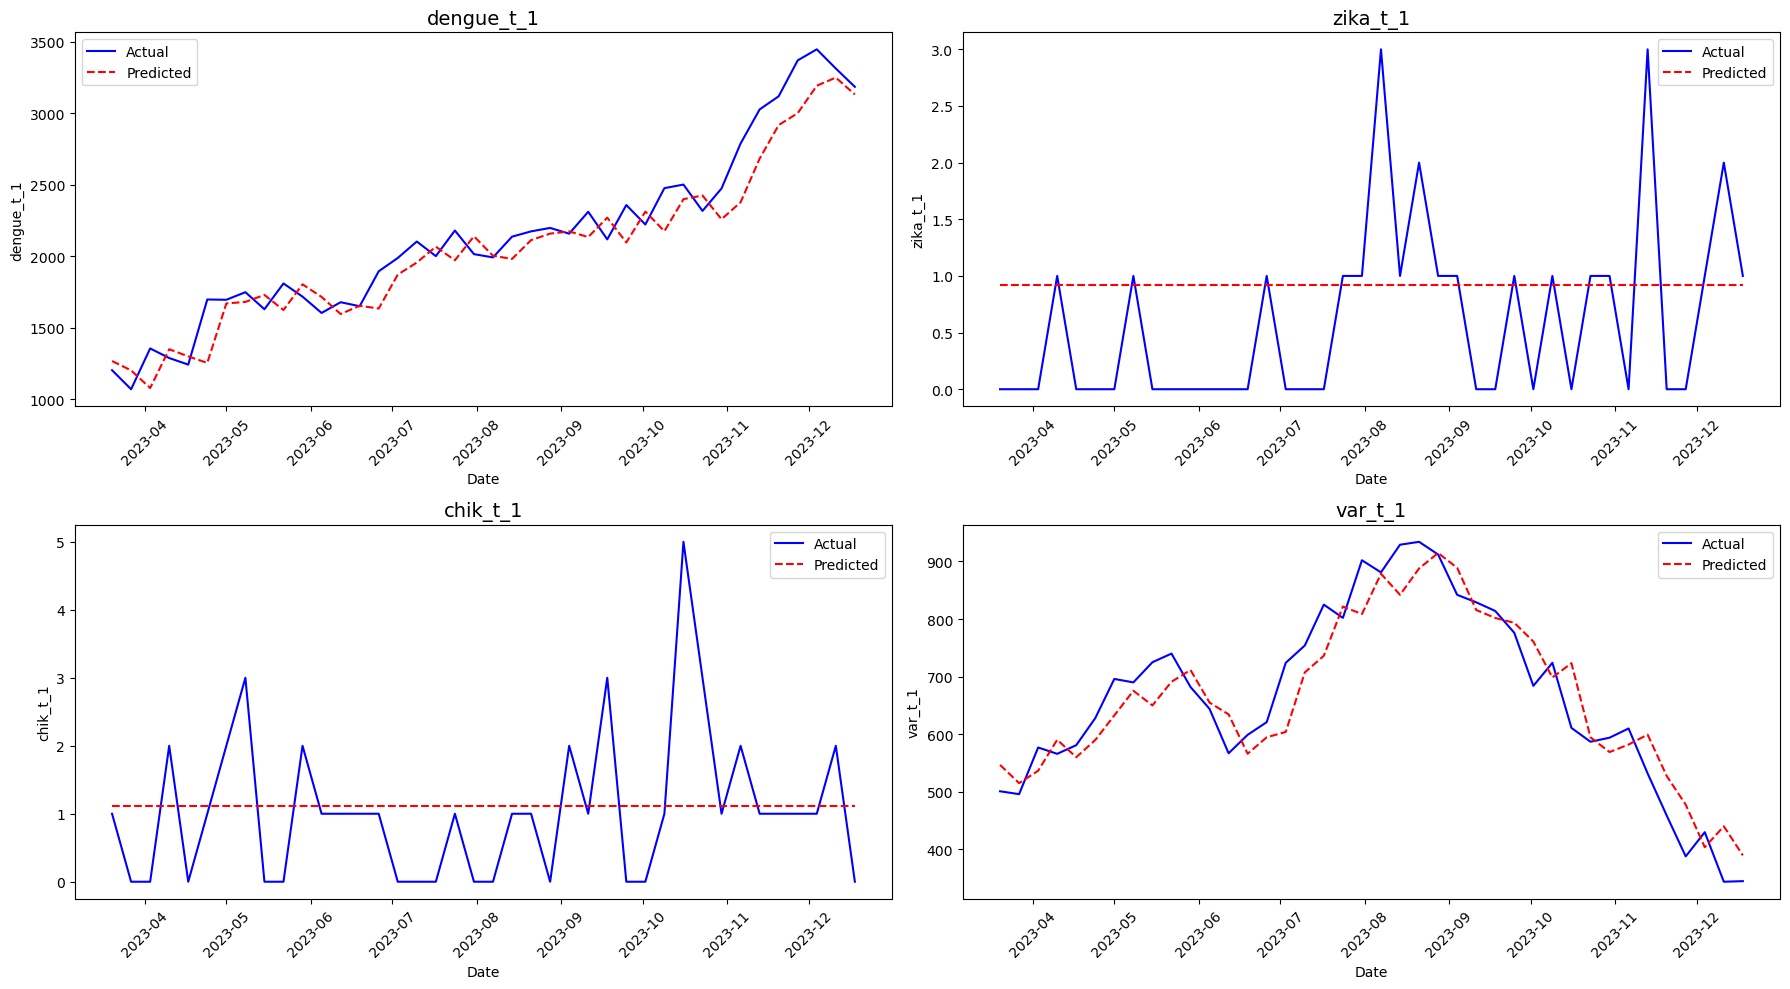

In [33]:
# Lasso
plot_predictions_cv_forecast(df, targets, Lasso(), n_splits=5)

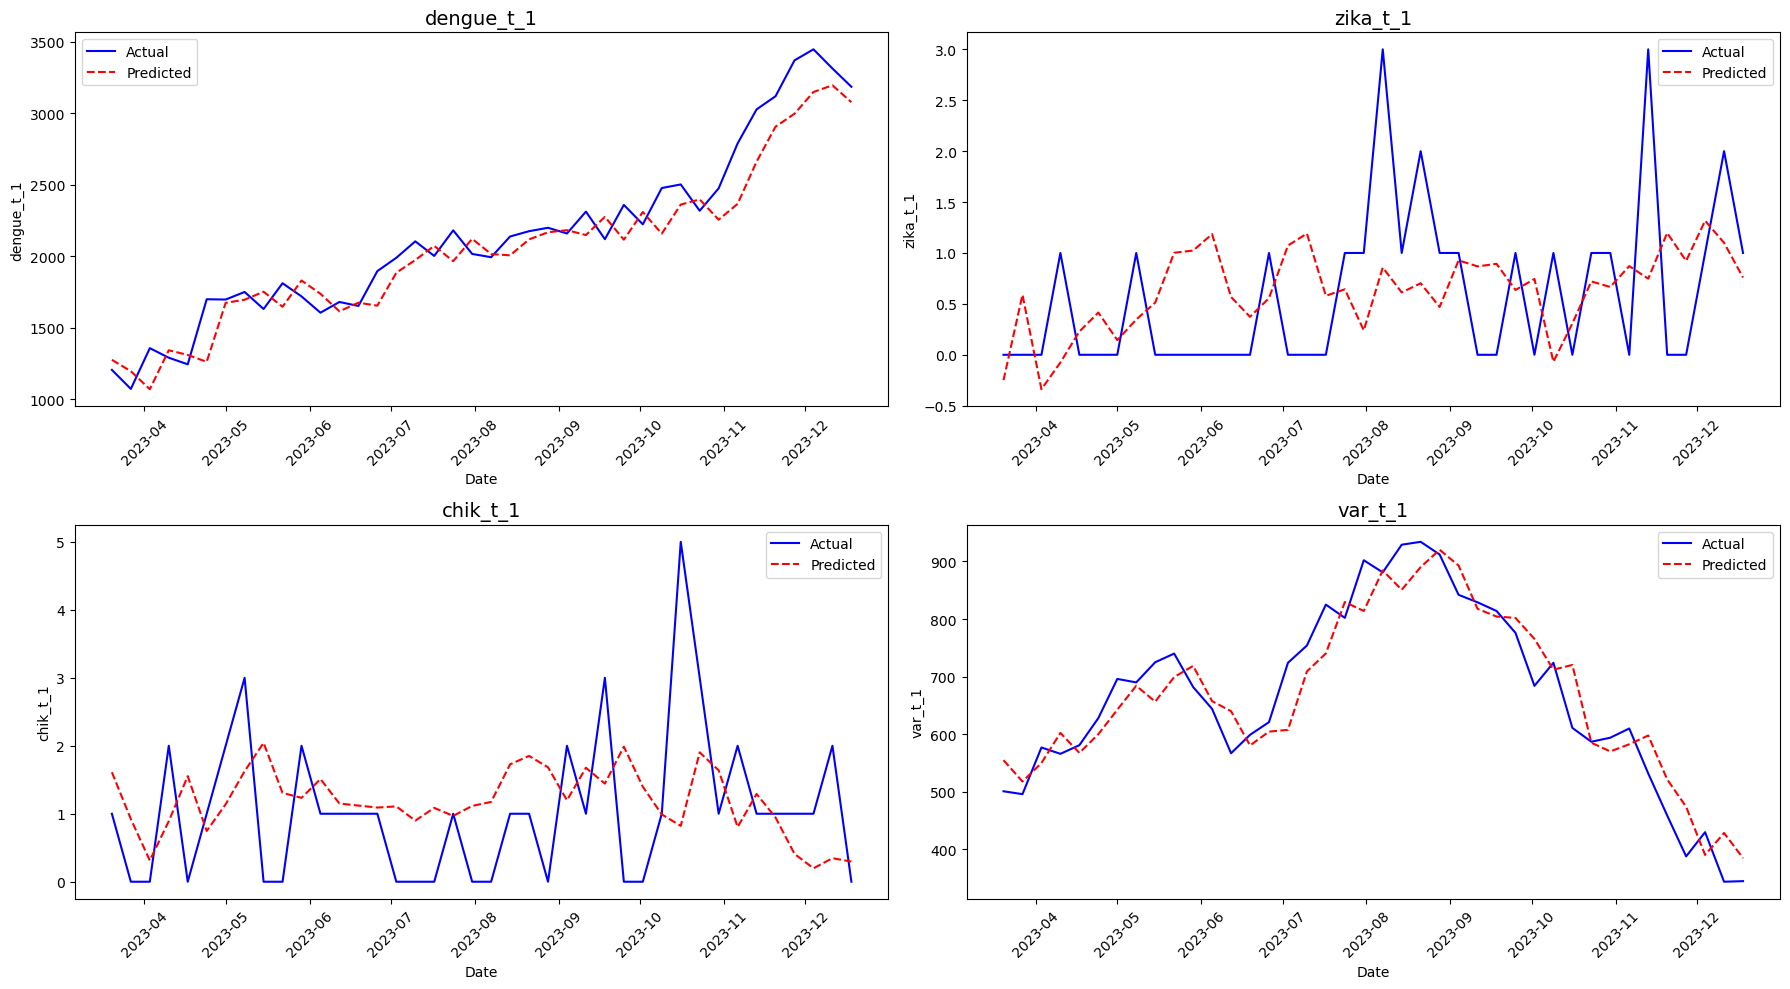

In [34]:
# Ridge
plot_predictions_cv_forecast(df, targets, Ridge(), n_splits=5)

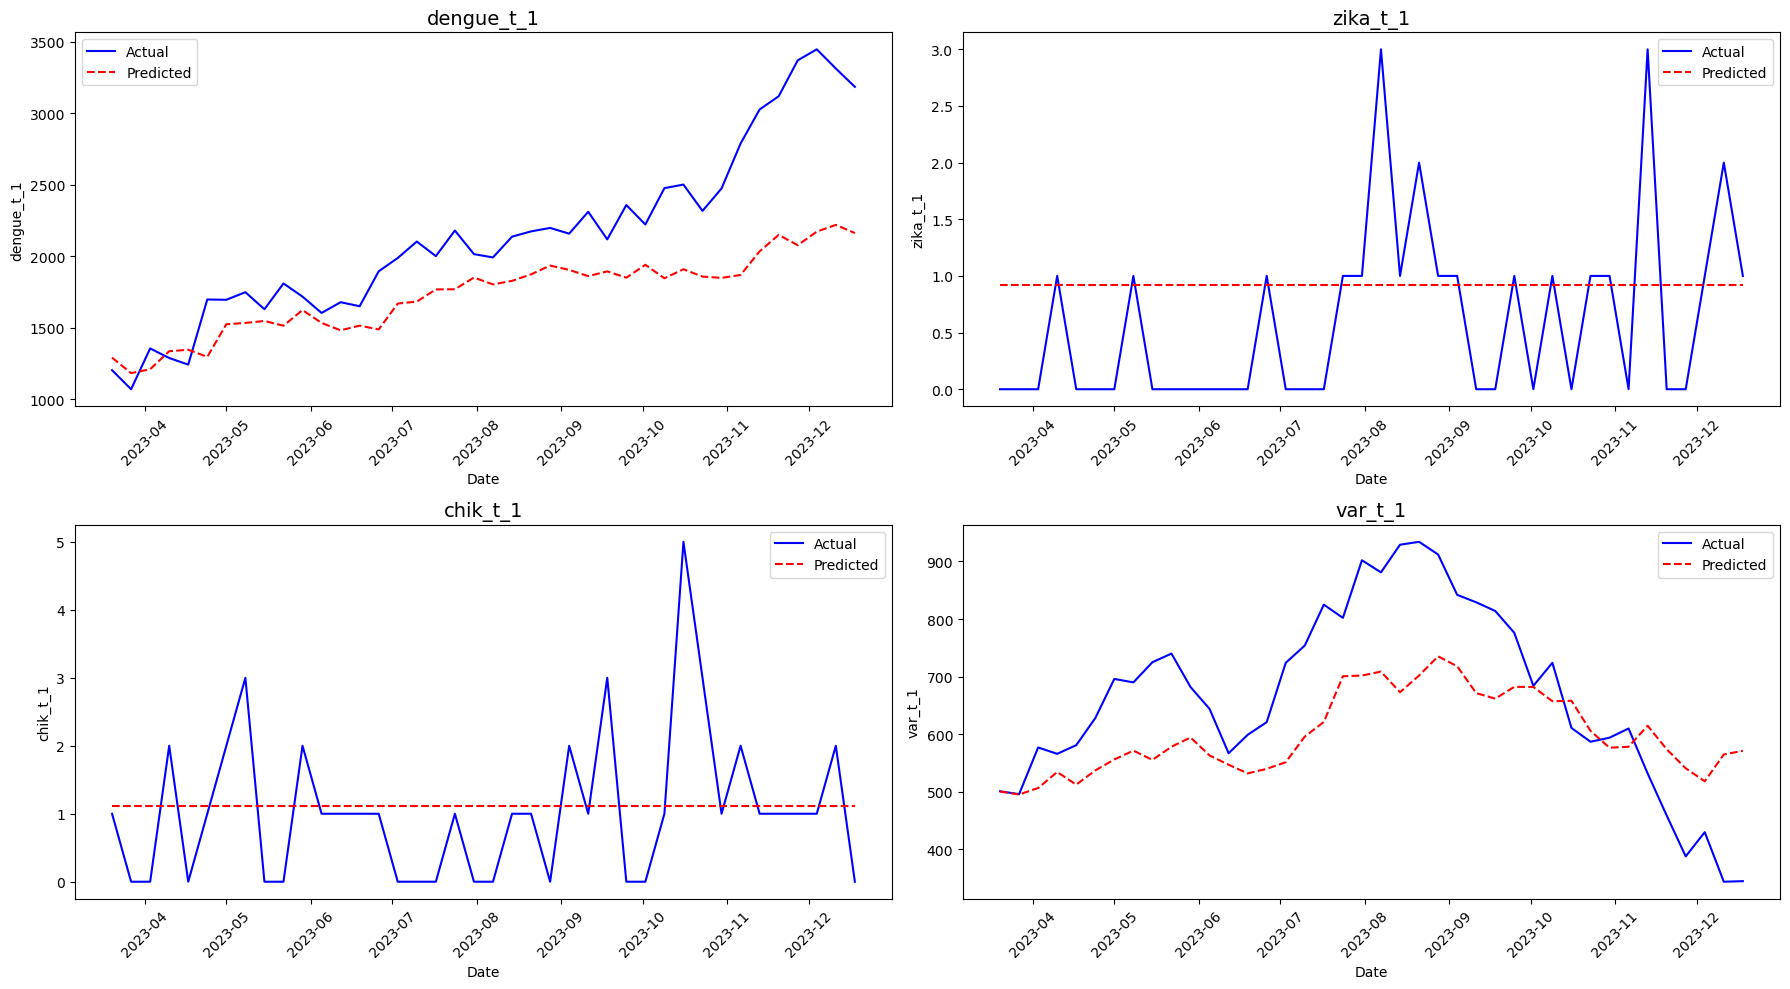

In [35]:
# ElasticNet
plot_predictions_cv_forecast(df, targets, ElasticNet(alpha = 1, l1_ratio=0.5), n_splits=5)

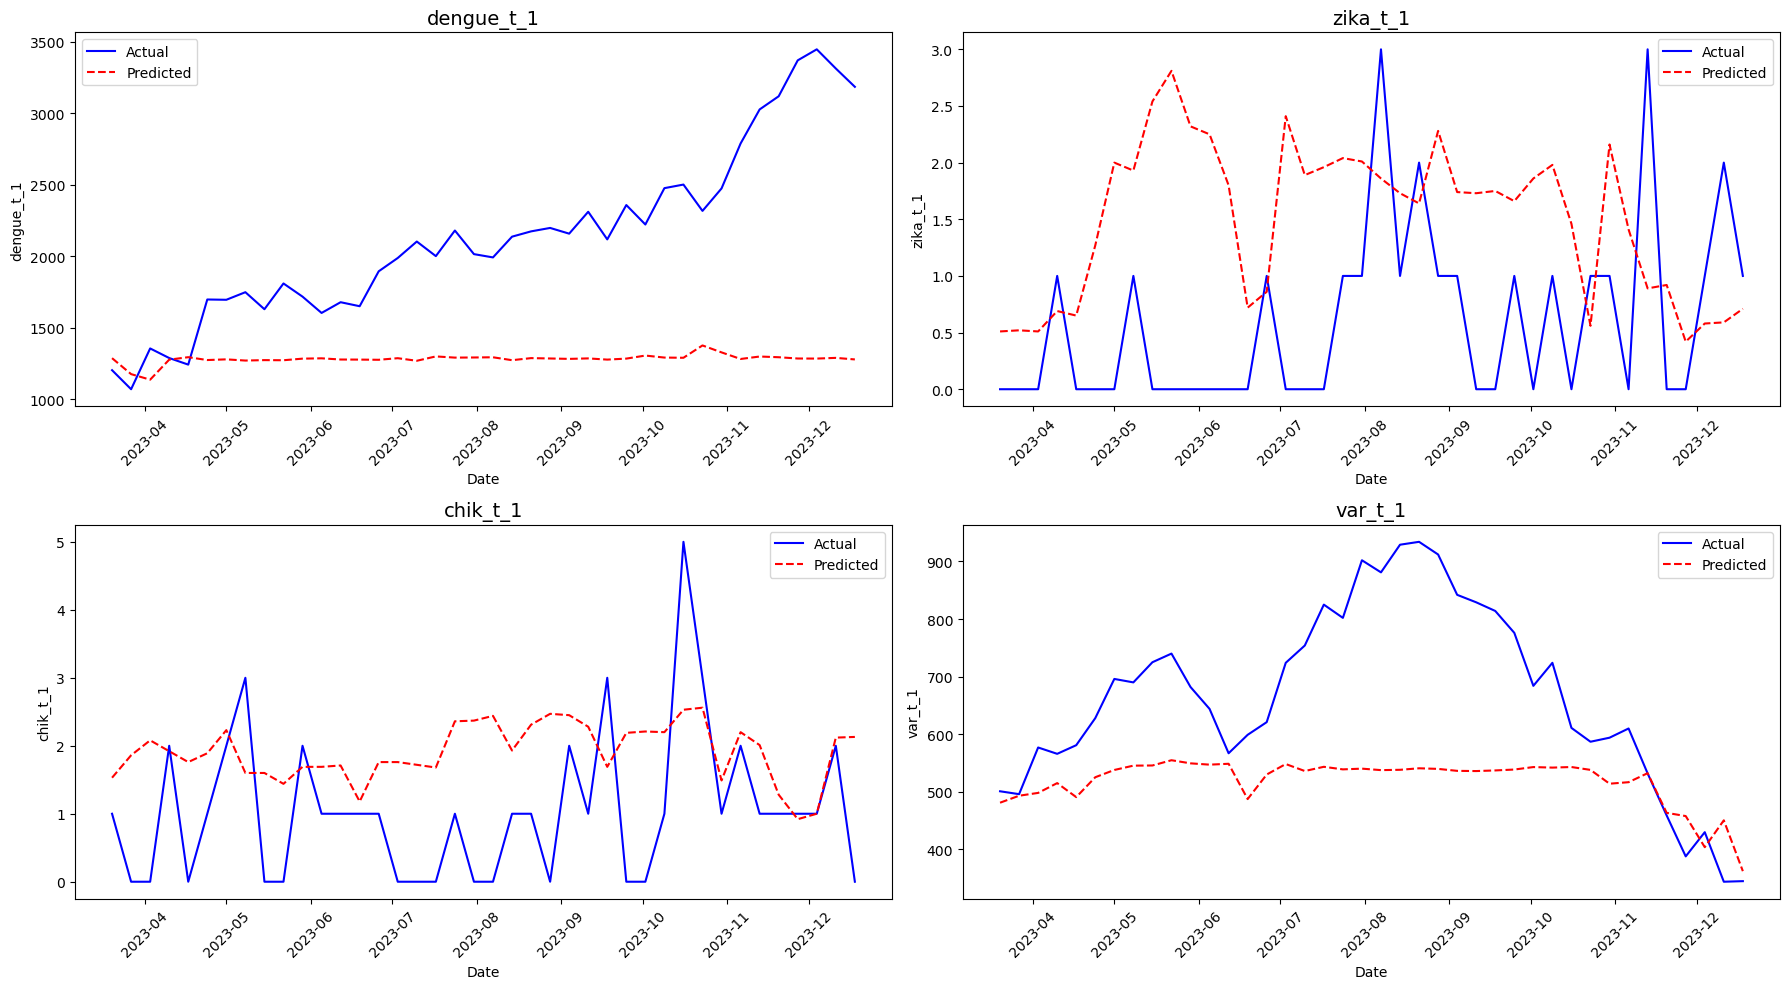

In [36]:
# RF
plot_predictions_cv_forecast(df, targets, RandomForestRegressor(n_estimators=100, random_state=42), n_splits=5)

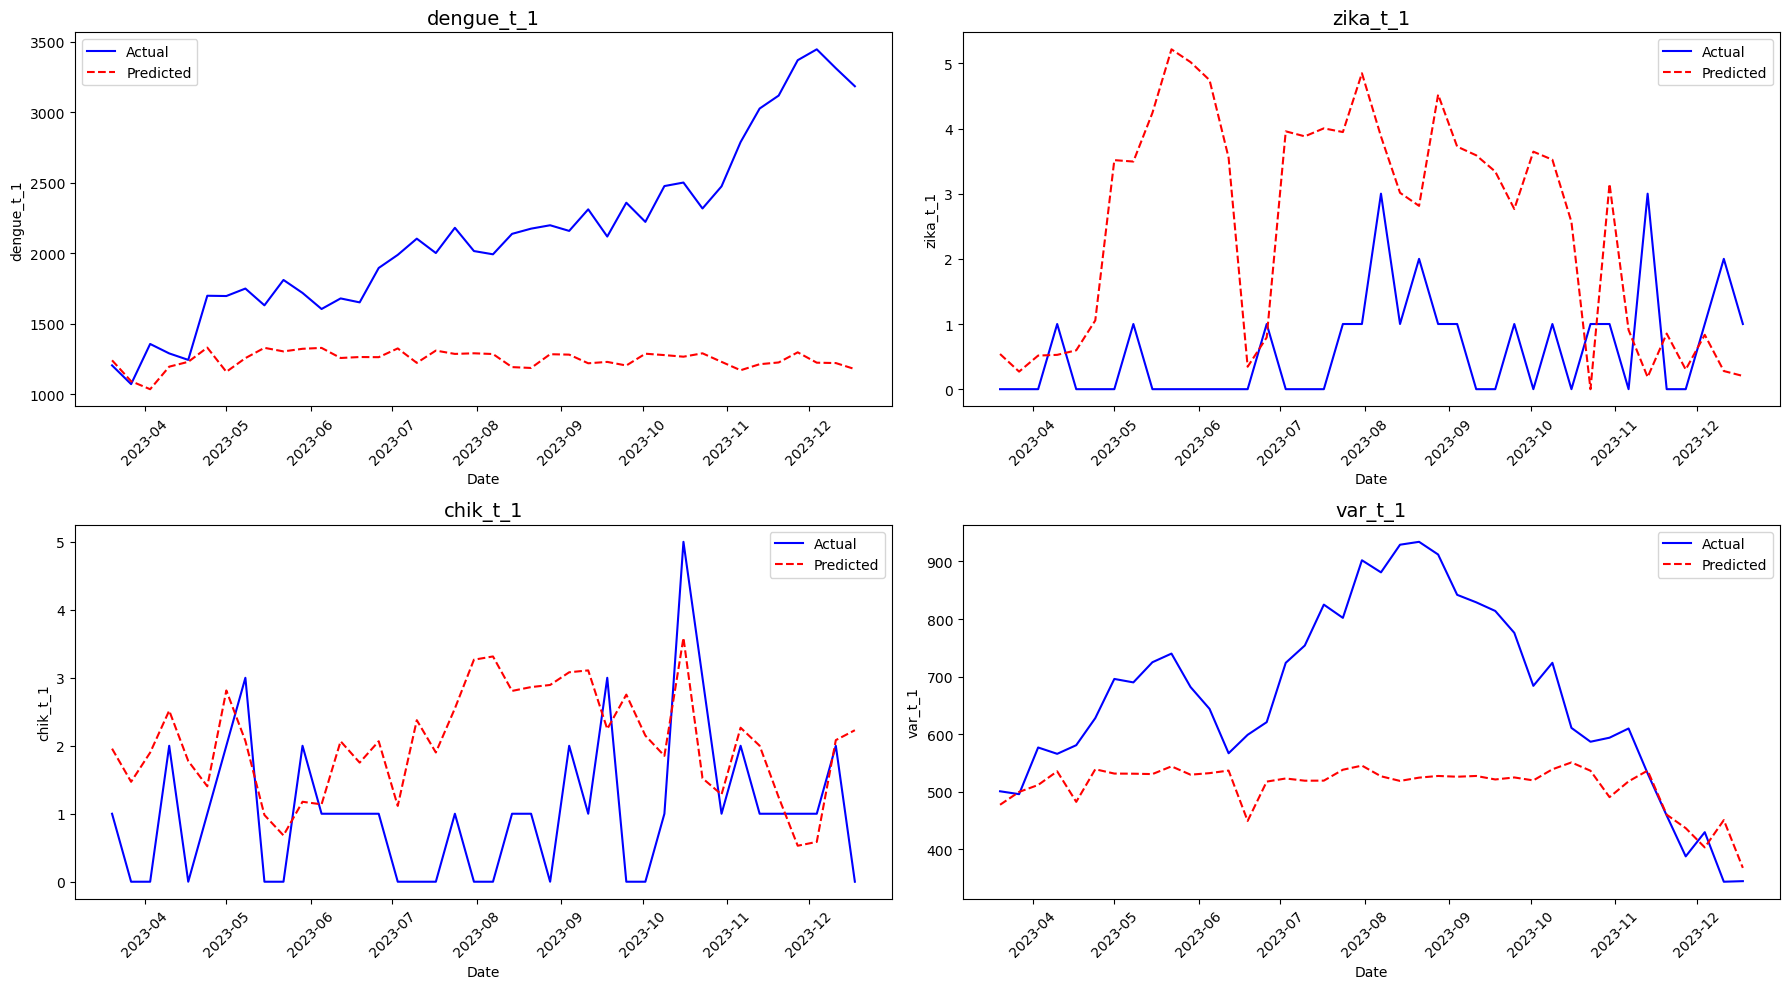

In [37]:
# Gradient Boosting
plot_predictions_cv_forecast(df, targets, GradientBoostingRegressor(n_estimators=100, random_state=42), n_splits=5)

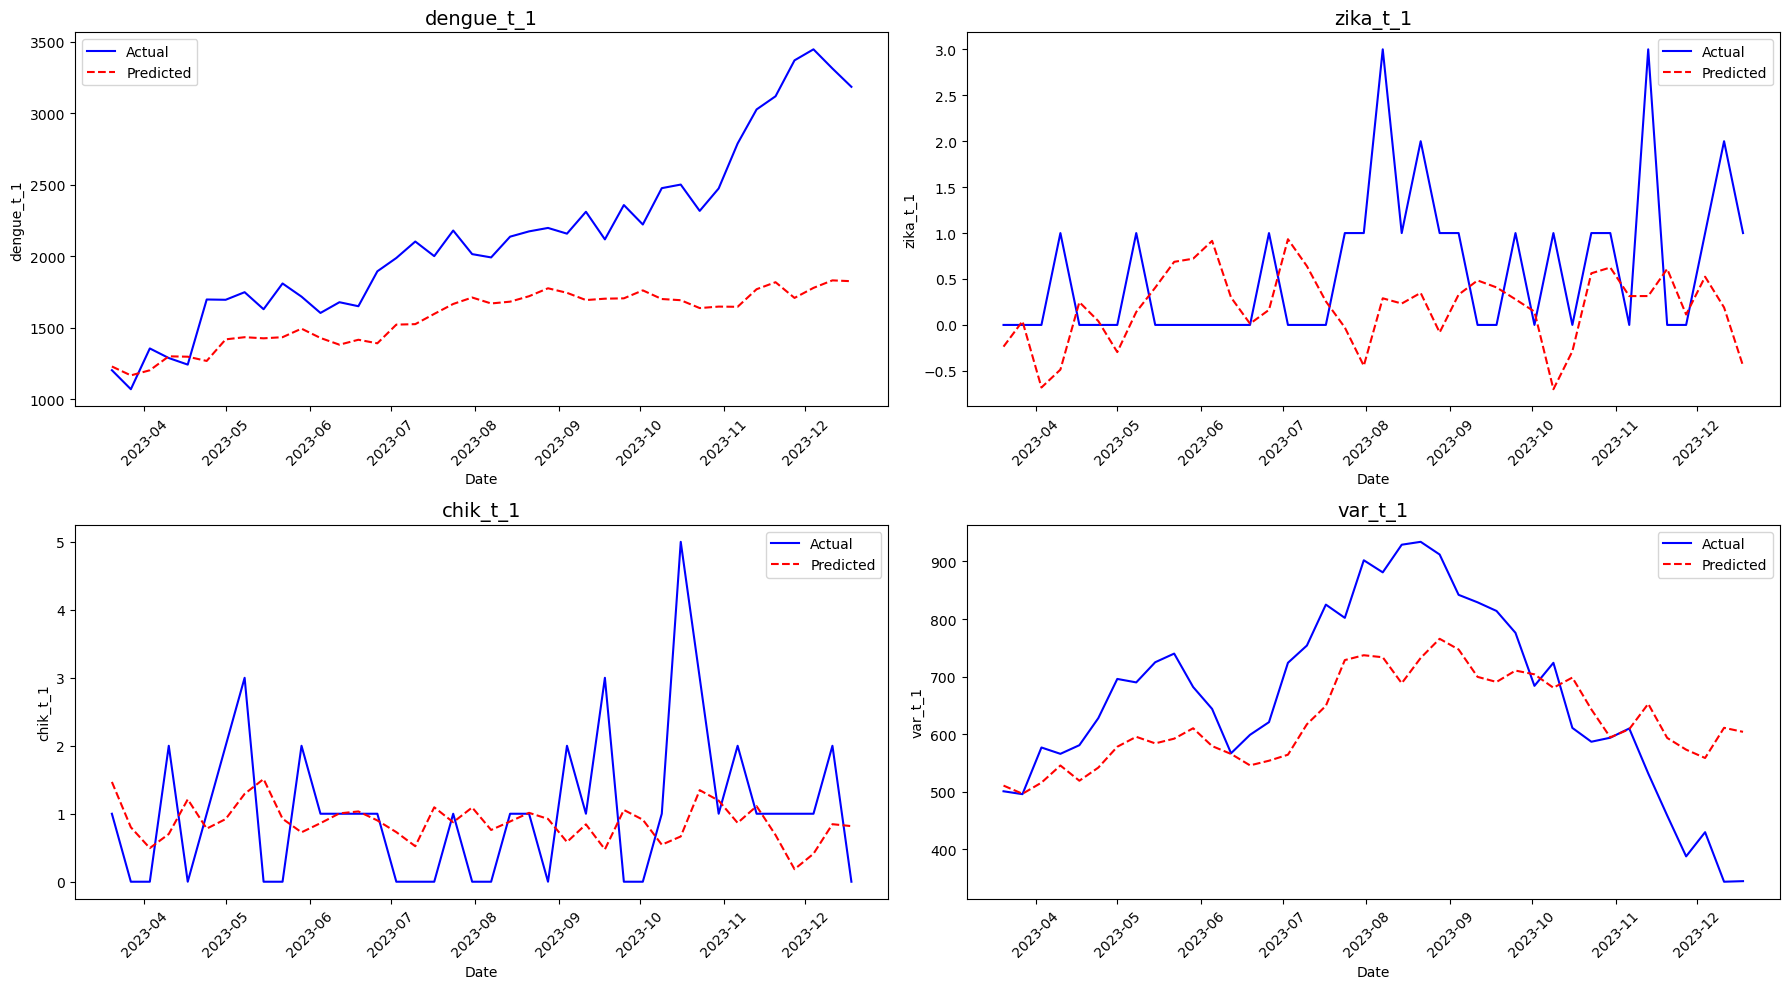

In [39]:
# SVM
plot_predictions_cv_forecast(df, targets,SVR(kernel='linear'), n_splits=5)

# Check Explainability

In [90]:
def plot_coefficients_by_country(df, target_variable, model):
    country_names = df['country'].unique()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, country_name in enumerate(country_names):
        country_df = df[df['country'] == country_name].reset_index(drop=True)

        split_country_idx = int(len(country_df) * 0.8)
        df_train = country_df.iloc[:split_country_idx]

        drop_columns = [target_variable, 'date', 'country']
        if target_variable == 'new_cases':
            drop_columns.extend(['cases', 'cases_t_4', 'cases_t_1'])
        elif target_variable == 'cases':
            drop_columns.extend(['new_cases', 'cases_t_4', 'cases_t_1'])
        elif target_variable == 'cases_t_4':
            drop_columns.extend(['cases_lag1', 'cases_t_1'])
        elif target_variable == 'cases_t_1':
            drop_columns.extend(['cases_lag1', 'cases_t_4'])

        X_train = df_train.drop(columns=drop_columns)
        y_train = df_train[target_variable]

        dummy_cols = [col for col in X_train.columns if set(X_train[col].unique()) <= {0, 1}]
        numeric_cols = [col for col in X_train.columns if col not in dummy_cols]

        scaler = StandardScaler()
        X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
        X_train_scaled = np.concatenate([X_train_scaled_numeric, X_train[dummy_cols].values], axis=1)

        feature_names = numeric_cols + dummy_cols

        model.fit(X_train_scaled, y_train)

        if hasattr(model, 'coef_'):
            importance = model.coef_
            title = "Coefficients"
        elif hasattr(model, 'feature_importances_'):
            importance = model.feature_importances_
            title = "Feature Importances"
        else:
            raise ValueError("Model does not have coefficients or feature importances to plot.")

        sorted_idx = np.argsort(np.abs(importance))[::-1]

        axes[idx].bar(np.array(feature_names)[sorted_idx], importance[sorted_idx])
        axes[idx].set_title(f"{country_name} - {title}", fontsize=14)
        axes[idx].set_xlabel("Features", fontsize=12)
        axes[idx].set_ylabel(title, fontsize=12)
        axes[idx].tick_params(axis='x', rotation=90)

    for i in range(len(country_names), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()




## OLS

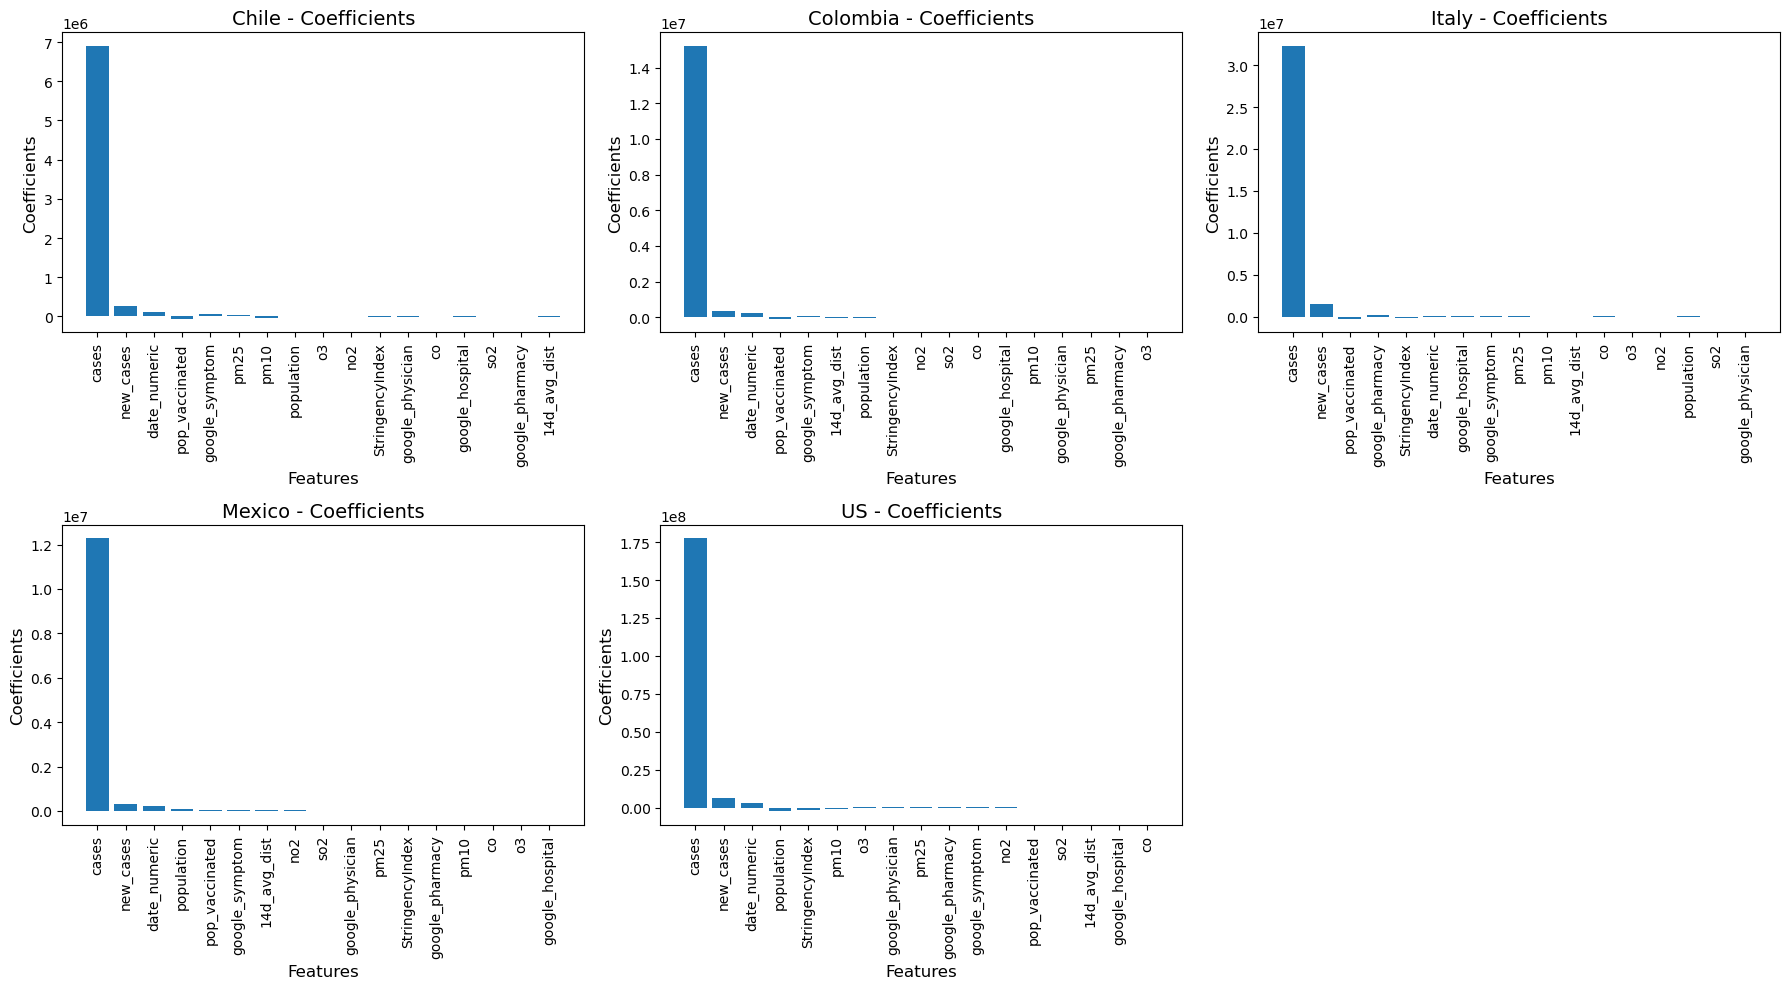

In [91]:
plot_coefficients_by_country(df_og, 'cases_t_1', LinearRegression())

## Lasso

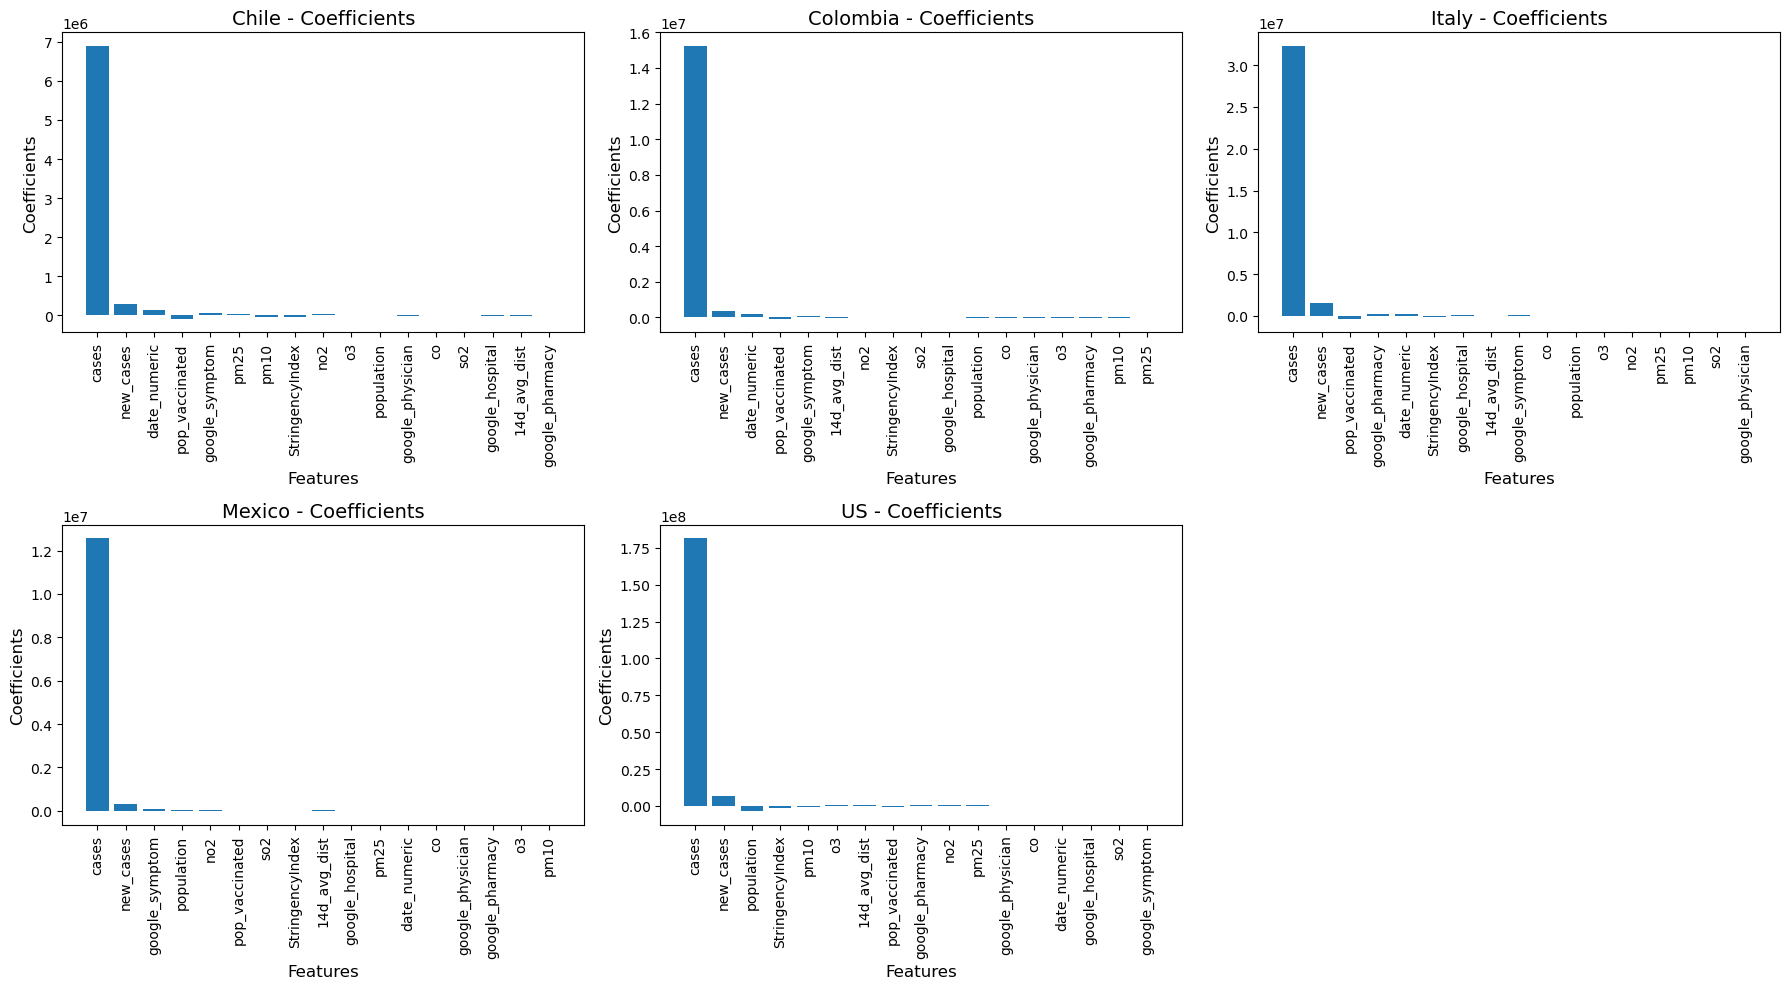

In [92]:
plot_coefficients_by_country(df_og, 'cases_t_1', Lasso())

## Ridge

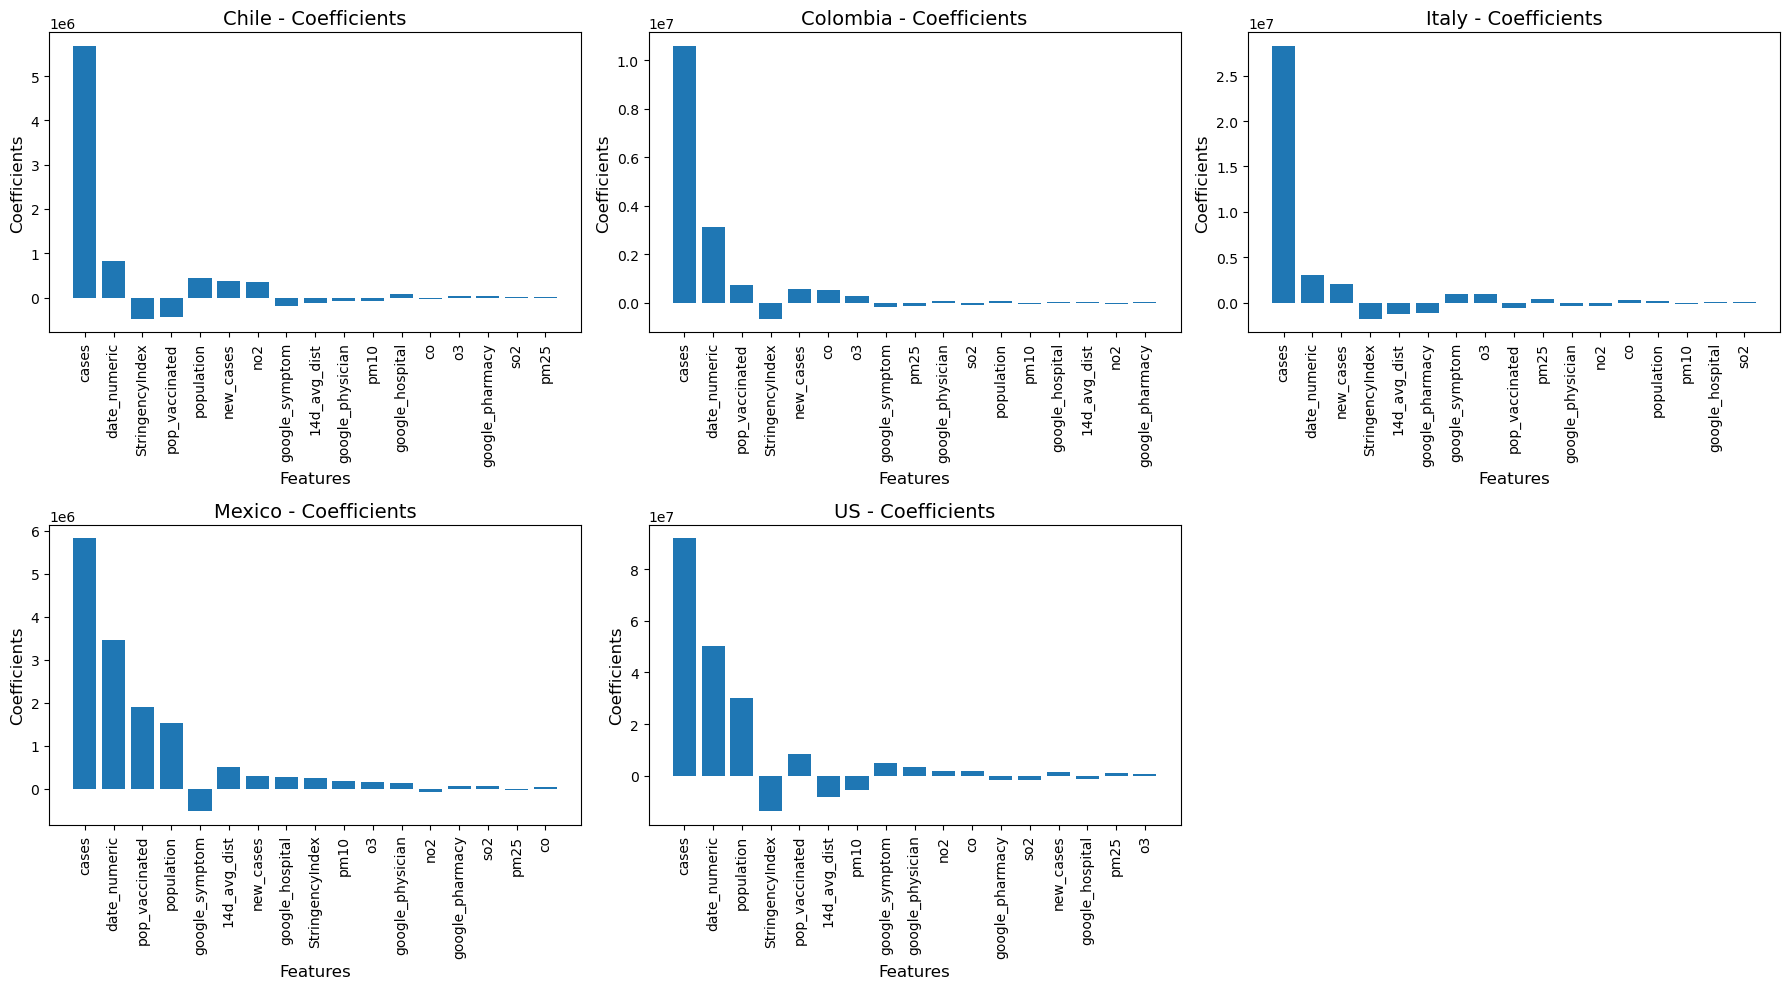

In [93]:
plot_coefficients_by_country(df_og, 'cases_t_1', Ridge())

## ElasticNet

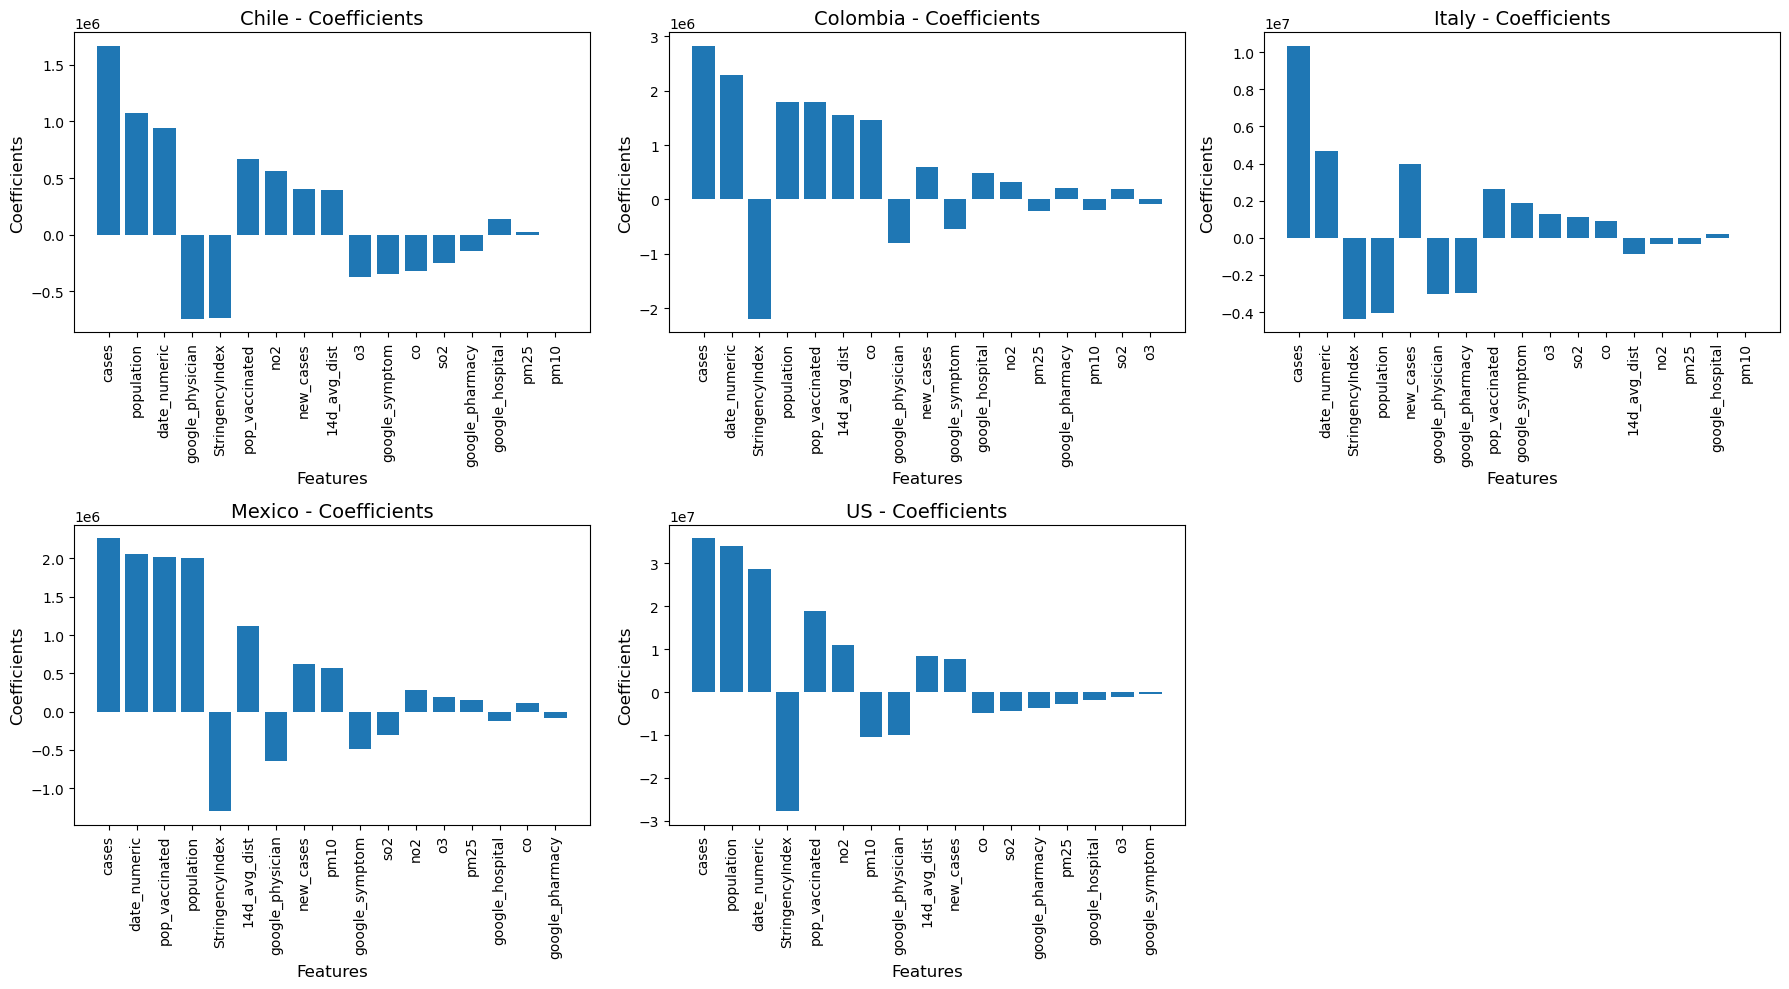

In [94]:
plot_coefficients_by_country(df_og, 'cases_t_1', ElasticNet())

## Random Forest

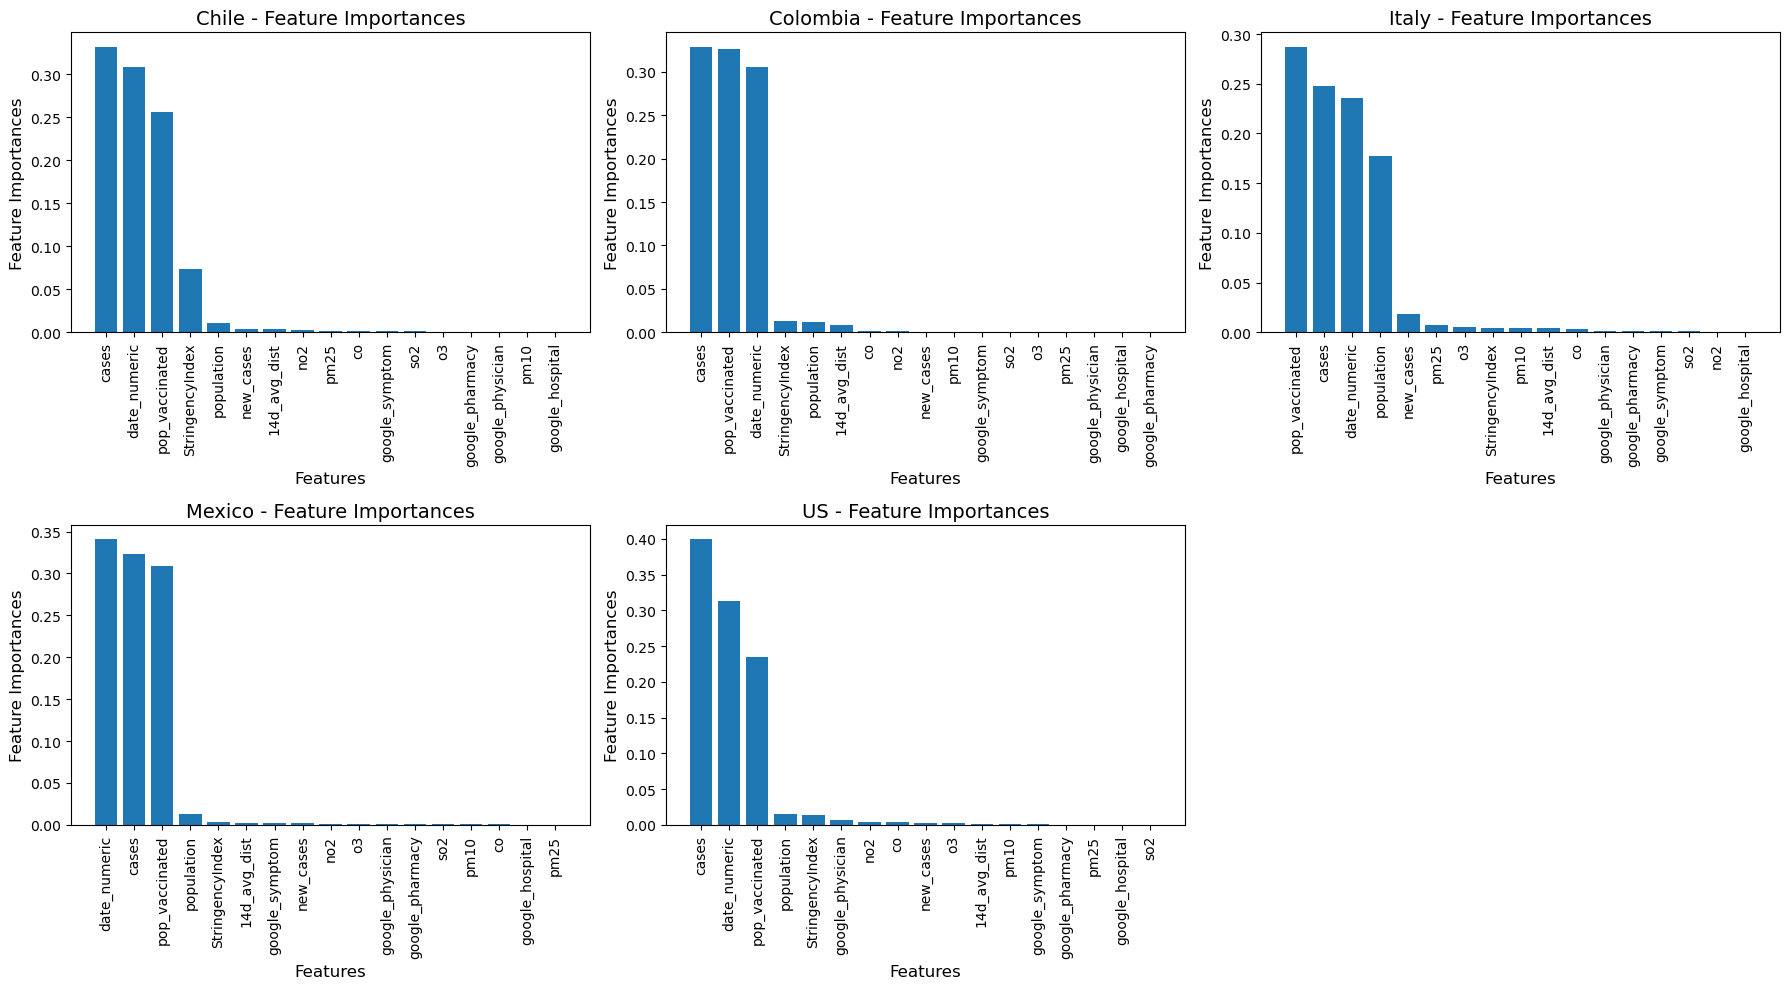

In [95]:
plot_coefficients_by_country(df_og, 'cases_t_1', RandomForestRegressor())

## Gradient Boosting

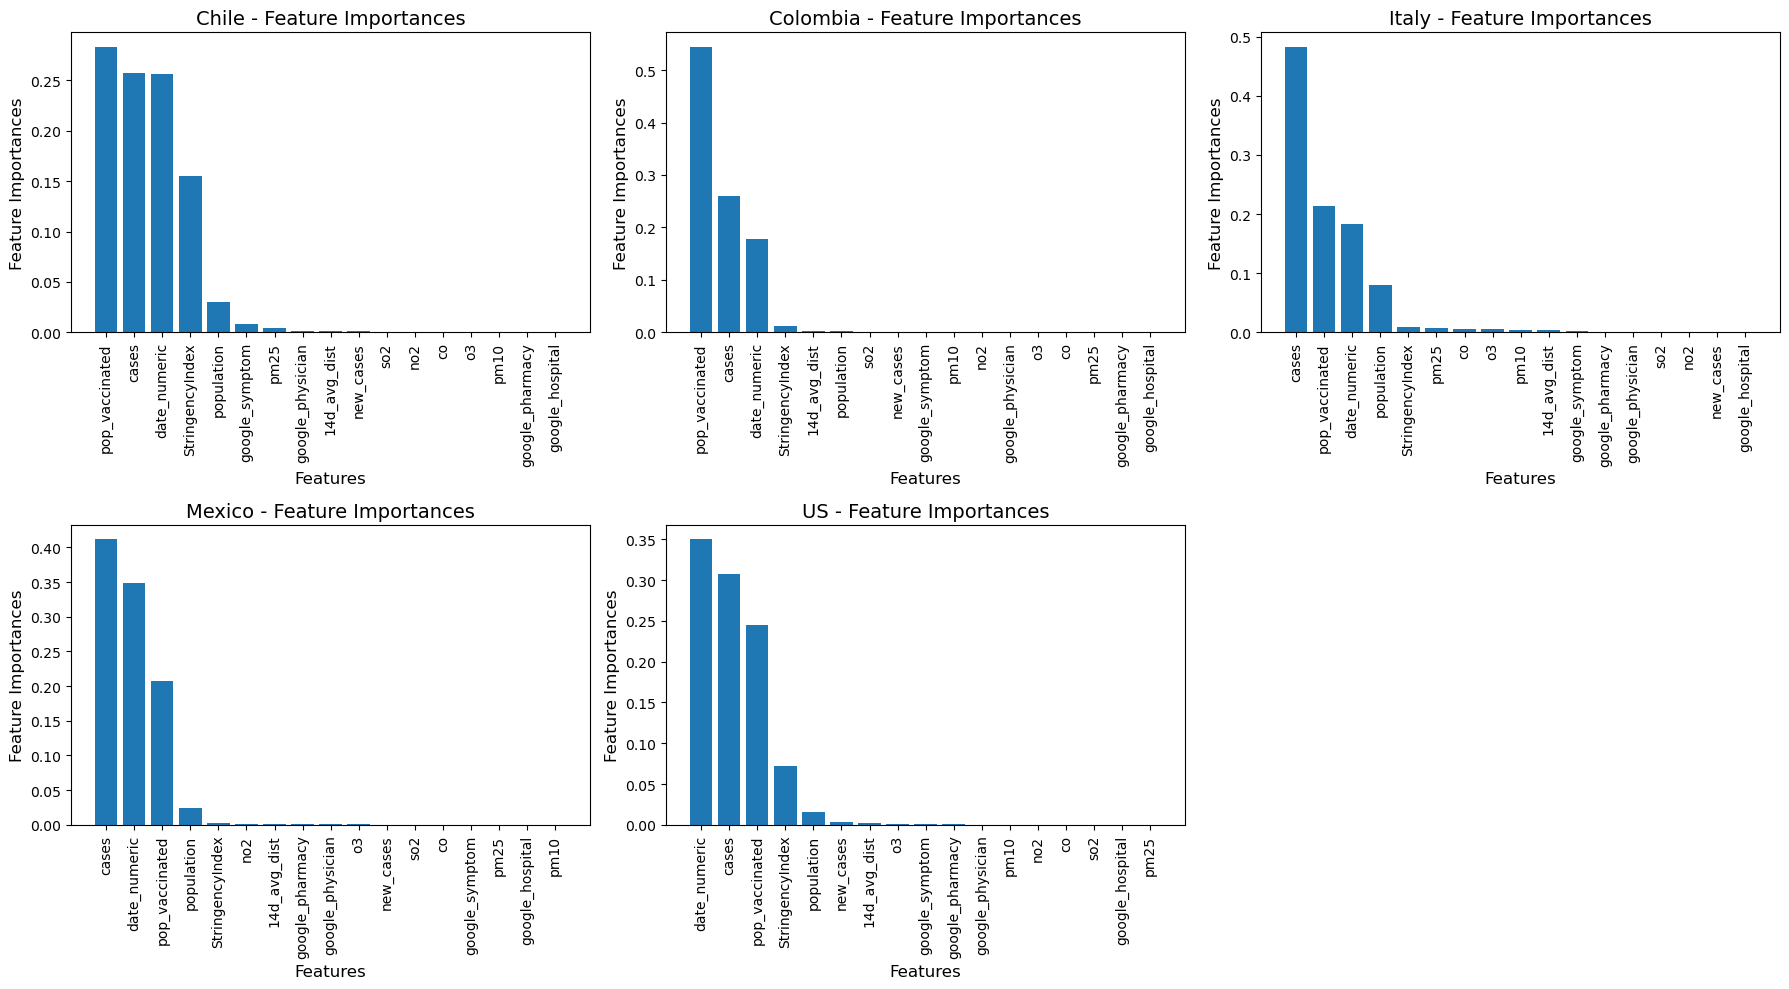

In [96]:
plot_coefficients_by_country(df_og, 'cases_t_1', GradientBoostingRegressor())

# Feature Engineering

Find the lags that best predict the ```cases_t_1``` for each variable and contrast to each ```country```

In [88]:
def variable_lag_impact(df, target_variable, max_lag=5):
    country_names = df['country'].unique()
    results = {}

    for country_name in country_names:
        country_df = df[df['country'] == country_name].reset_index(drop=True)

        drop_columns = [target_variable, 'date', 'country']
        if target_variable == 'new_cases':
            drop_columns.extend(['cases', 'cases_t_4', 'cases_t_1'])
        elif target_variable == 'cases':
            drop_columns.extend(['new_cases', 'cases_t_4', 'cases_t_1'])
        elif target_variable == 'cases_t_4':
            drop_columns.extend(['cases_lag1', 'cases_t_1'])
        elif target_variable == 'cases_t_1':
            drop_columns.extend(['cases_lag1', 'cases_t_4'])

        variables = [col for col in country_df.columns if col not in drop_columns]
        corr_dict = {}

        for var in variables:
            lag_corrs = []
            for lag in range(1, max_lag + 1):
                shifted_var = country_df[var].shift(lag)
                corr = country_df[target_variable].corr(shifted_var)
                lag_corrs.append(corr)
            corr_dict[var] = lag_corrs

        results[country_name] = pd.DataFrame(corr_dict, index=[f'lag_{i}' for i in range(1, max_lag + 1)]).T

    return results

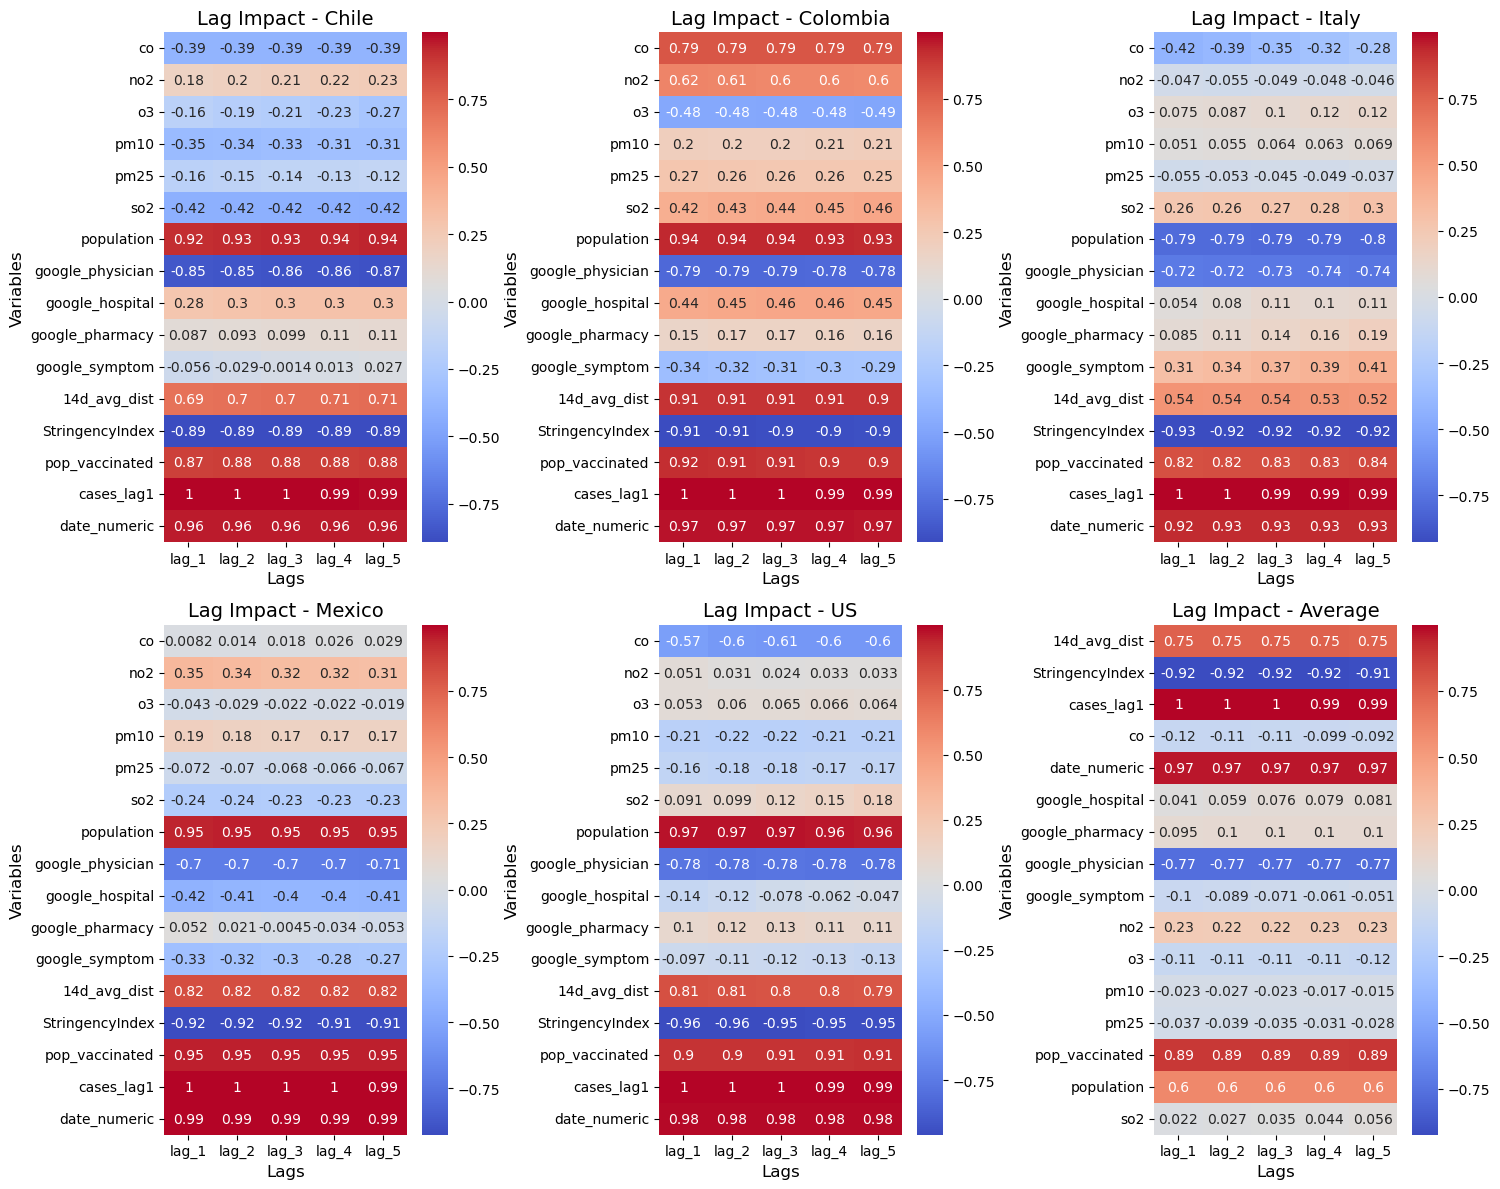

In [89]:
results = variable_lag_impact(df_og, target_variable='cases', max_lag=5)

country_names = list(results.keys())
n_cols = (len(country_names) + 2) // 2
fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 12))
axes = axes.flatten()

# Plot country-specific heatmaps
for idx, country_name in enumerate(country_names):
    sns.heatmap(results[country_name], annot=True, cmap='coolwarm', ax=axes[idx])
    axes[idx].set_title(f'Lag Impact - {country_name}', fontsize=14)
    axes[idx].set_xlabel('Lags', fontsize=12)
    axes[idx].set_ylabel('Variables', fontsize=12)

# Compute average table
average_df = pd.concat(results.values()).groupby(level=0).mean()

# Plot average heatmap
sns.heatmap(average_df, annot=True, cmap='coolwarm', ax=axes[len(country_names)])
axes[len(country_names)].set_title('Lag Impact - Average', fontsize=14)
axes[len(country_names)].set_xlabel('Lags', fontsize=12)
axes[len(country_names)].set_ylabel('Variables', fontsize=12)

# Remove empty subplots
for idx in range(len(country_names) + 1, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

Overall is ok to use just one lag for the covariates